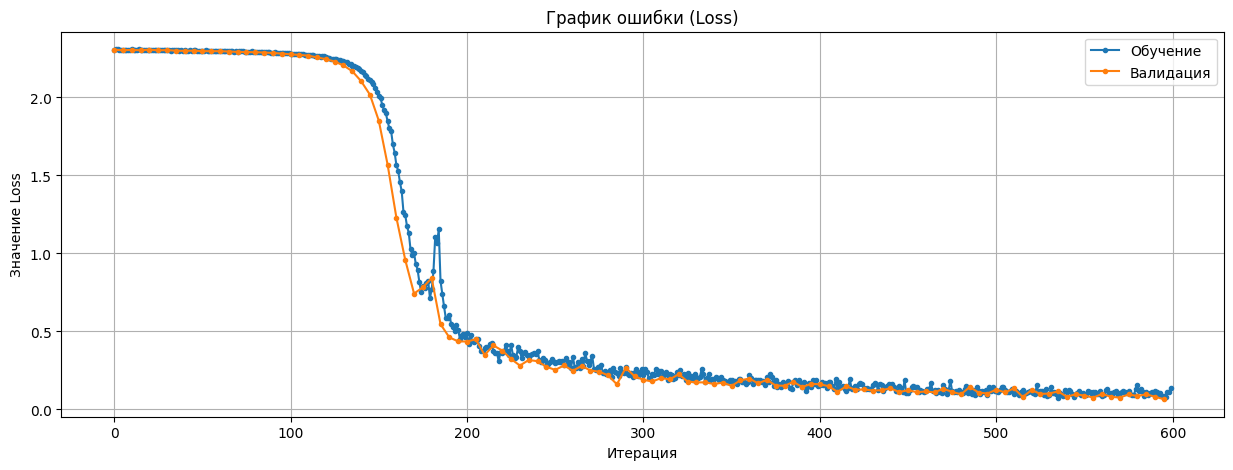

Итоговая точность (Accuracy) на валидации: 97.32%


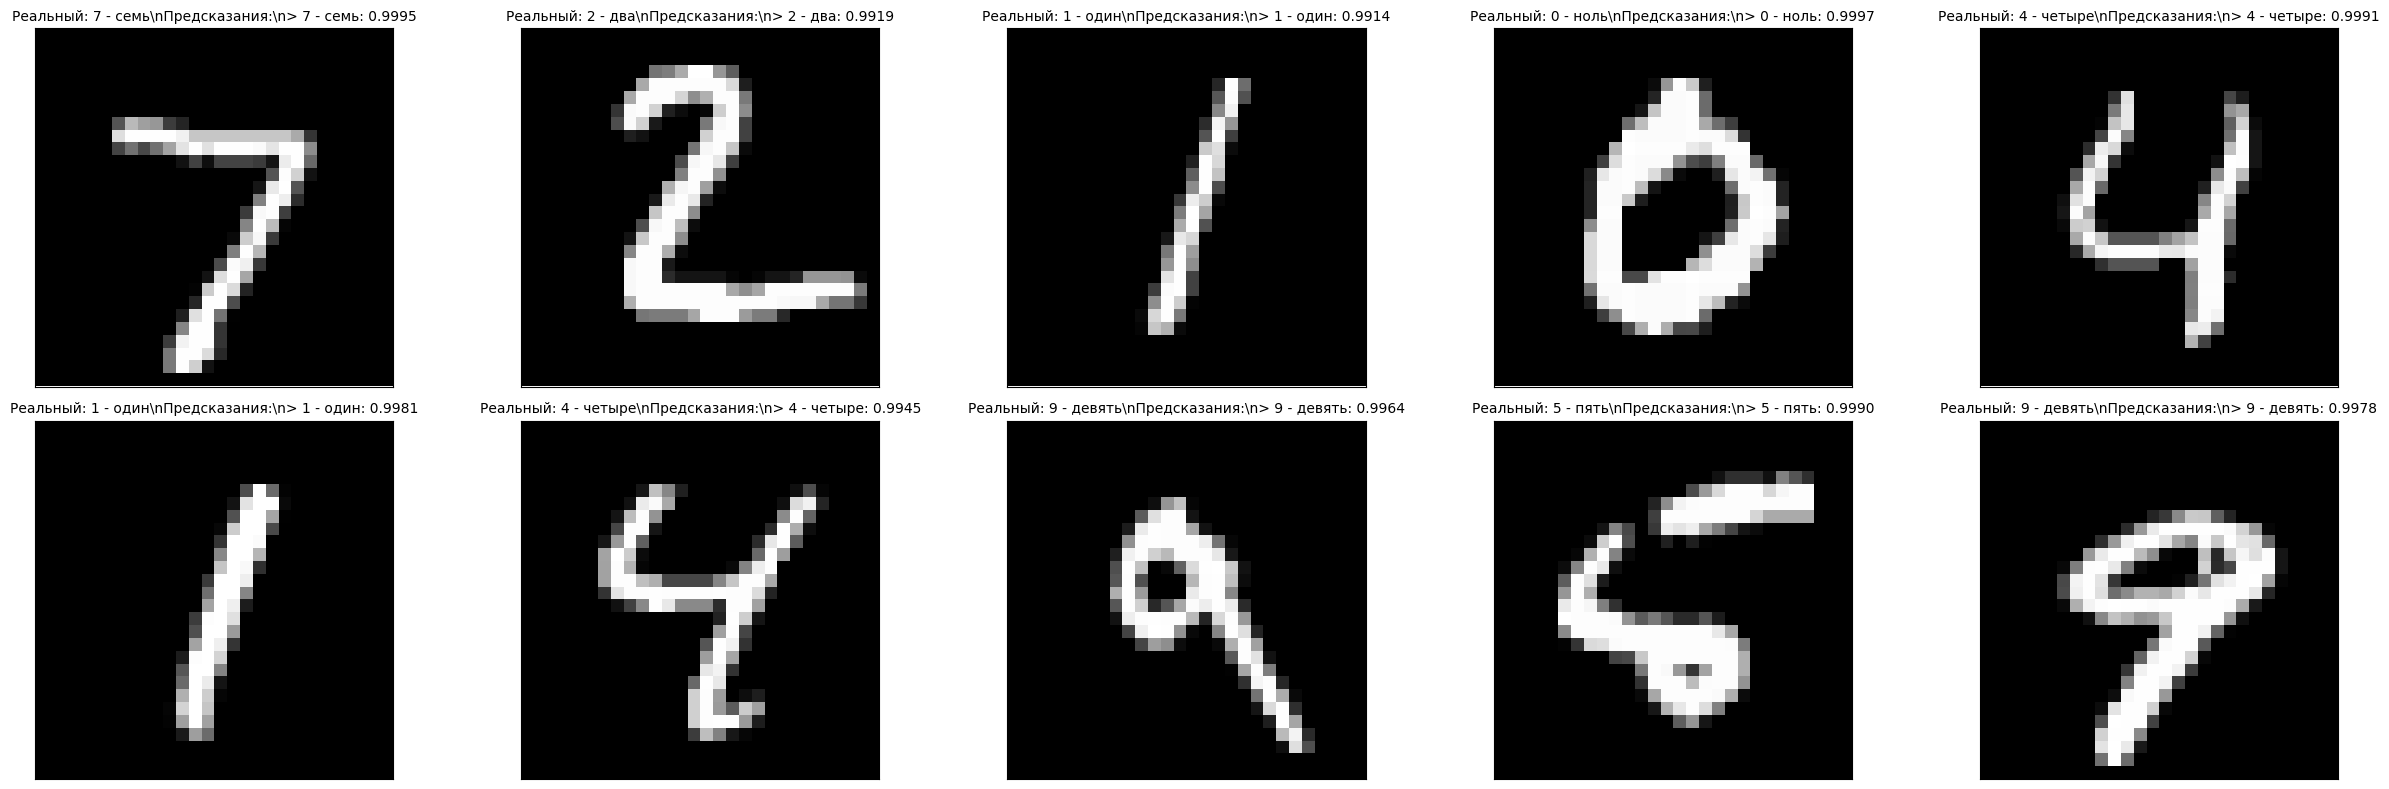

In [3]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.nn import Linear, Conv2d, ReLU, Softmax, MaxPool2d, Flatten, Sequential
from IPython.display import clear_output
download_dir = "./dataset"

train_data = datasets.MNIST(root=download_dir, download=True, train=True)
val_data = datasets.MNIST(root=download_dir, download=True, train=False)
x_train = train_data.data.unsqueeze(1).float() / 255.0
y_train = train_data.targets

x_val = val_data.data.unsqueeze(1).float() / 255.0
y_val = val_data.targets

classes_ru = [
    "0 - ноль", "1 - один", "2 - два", "3 - три", "4 - четыре",
    "5 - пять", "6 - шесть", "7 - семь", "8 - восемь", "9 - девять",
]



le_net_seq = Sequential(
    Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2),  
    ReLU(),
    MaxPool2d(kernel_size=2),                                          
    
    Conv2d(in_channels=6, out_channels=16, kernel_size=5),             
    ReLU(),
    MaxPool2d(kernel_size=2),                                          
    
    Conv2d(in_channels=16, out_channels=120, kernel_size=5),           
    ReLU(),
    
    Flatten(),
    
    Linear(in_features=120, out_features=84),
    ReLU(),
    Linear(in_features=84, out_features=10),
    Softmax(dim=-1)
)

class LeNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.le_net = le_net_seq
        
    def forward(self, x):
        return self.le_net(x).log()

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

num_epochs = 600
batch_size = 1000
val_every = 5

model = LeNet().to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, nesterov=True)
loss_fn = torch.nn.NLLLoss()

losses = {"train": [], "val": []}

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    batch_pos = torch.randint(high=x_train.shape[0], size=[batch_size])
    x_batch = x_train[batch_pos].to(device)
    y_batch = y_train[batch_pos].to(device)
    pred = model(x_batch)
    loss = loss_fn(pred, y_batch)
    
    loss.backward()
    optimizer.step()
    
    losses["train"].append(loss.item())
    
    if epoch % val_every == 0:
        with torch.no_grad():
            val_batch_pos = torch.randint(high=x_val.shape[0], size=[batch_size])
            x_val_batch = x_val[val_batch_pos].to(device)
            y_val_batch = y_val[val_batch_pos].to(device)
            
            val_pred = model(x_val_batch)
            val_loss = loss_fn(val_pred, y_val_batch)
            losses["val"].append(val_loss.item())
    if epoch % 10 == 0:
        clear_output(True)
        fig, ax = plt.subplots(figsize=(15, 5))
        plt.title("График ошибки (Loss)")
        plt.plot(losses["train"], ".-", label="Обучение")
        plt.plot(torch.arange(0, epoch, val_every), losses["val"], ".-", label="Валидация")
        plt.xlabel("Итерация")
        plt.ylabel("Значение Loss")
        plt.legend()
        plt.grid()
        plt.show()

with torch.no_grad():
    pred_sub = model(x_val.to(device)).max(1).indices
    acc_score = (y_val.to(device) == pred_sub).to(dtype=torch.float).mean().item()
    print(f'Итоговая точность (Accuracy) на валидации: {acc_score:.2%}')

def show_results(model, h=2, w=6):
    with torch.no_grad():
        x_val_batch = x_val[:h*w].to(device)
        batch_probs = model(x_val_batch).exp()

        fig, ax = plt.subplots(h, w, figsize=(25, 4 * h))
        for i in range(h * w):
            plt.subplot(h, w, i+1)
            plt.imshow(x_val[i].squeeze(0).cpu(), cmap='gray')
            
            title = f'Реальный: {classes_ru[y_val[i]]}\\nПредсказания:'
            y_pred = torch.argmax(batch_probs[i])
            
            for j, prob in enumerate(batch_probs[i]):
                if prob.item() > 0.01:
                    title += f'\\n{"> " if j == y_pred else ""}{classes_ru[j]}: {prob.item():.4f}'
                
            plt.title(title, fontsize=10)
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.show()

show_results(model, h=2, w=5)